In [3]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from BaselineRemoval import BaselineRemoval
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import tqdm as tqdm

## Define Functions to Load and Manipulate Data

In [4]:
def no_processing(data_paths, labels, delim=","):
    data = pd.DataFrame()
    for data_path, label in zip(data_paths, labels):    
        l = [pd.read_csv(filename,header=None,index_col=0, names=[label], delimiter = delim) for filename in glob.glob(data_path)]
        new_data = pd.concat(l, ignore_index=False, axis=1)
        data = pd.concat([data, new_data], ignore_index=False, axis=1)
    return data.T

## Experiment 1
### Load Data

In [5]:
fps = ["./data/exp1/0/*.csv", "./data/exp1/1/*.csv", "./data/exp1/3/*.csv"]
labels = ["0 cm", "1 cm", "3 cm"]

In [6]:
data_exp1 = no_processing(fps, labels)
cols_to_drop = [col for col in data_exp1.columns if col <= 4500]
data_exp1 = data_exp1.drop(columns=cols_to_drop)
data_exp1

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.040,4531.896,4535.754,...,9966.316,9970.173,9974.030,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.030
0 cm,1.120757,1.119793,1.114723,1.116301,1.107698,1.114415,1.126113,1.110027,1.103165,1.097828,...,0.711451,0.710160,0.713403,0.715666,0.714641,0.714979,0.711499,0.709979,0.709667,0.708035
0 cm,1.077184,1.076381,1.076977,1.075171,1.068235,1.061145,1.064221,1.047787,1.044378,1.043219,...,0.729058,0.731111,0.732254,0.732895,0.729472,0.728132,0.729998,0.731753,0.729643,0.729848
0 cm,-0.000885,0.000656,0.001046,0.000631,0.000244,0.001172,0.002655,0.001862,0.000525,0.000433,...,0.001368,0.000895,-0.000669,-0.002028,-0.000868,-0.000506,0.000362,0.001234,0.001347,0.001041
0 cm,1.115710,1.119943,1.125476,1.128045,1.111767,1.104266,1.094517,1.090636,1.096001,1.093752,...,0.728984,0.734207,0.733366,0.734080,0.740061,0.734486,0.737650,0.742102,0.736200,0.734009
0 cm,1.080874,1.078723,1.080181,1.084030,1.078129,1.074423,1.068282,1.059042,1.059491,1.064329,...,0.705907,0.706305,0.705289,0.706445,0.707405,0.704971,0.705173,0.704316,0.703989,0.705072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3 cm,1.769095,1.783057,1.728964,1.690261,1.697086,1.750748,1.753652,1.722892,1.749410,1.770124,...,1.553823,1.587427,1.567716,1.534369,1.542734,1.559594,1.574559,1.547749,1.525904,1.525600
3 cm,1.723626,1.783546,1.806294,1.801834,1.770977,1.731713,1.731209,1.758986,1.732539,1.734776,...,1.559246,1.555063,1.568753,1.541042,1.523935,1.538431,1.565728,1.591417,1.562820,1.540933
3 cm,1.769032,1.737509,1.719312,1.746498,1.765561,1.705947,1.691789,1.710435,1.716322,1.739033,...,1.528422,1.518602,1.503560,1.499207,1.517184,1.519455,1.533006,1.524626,1.542331,1.548445
3 cm,1.739095,1.823056,1.868919,1.768374,1.748049,1.778932,1.747620,1.747258,1.696668,1.671250,...,1.495841,1.536436,1.561360,1.578614,1.551125,1.522274,1.537088,1.534559,1.495319,1.468078


### Plot Spectrum

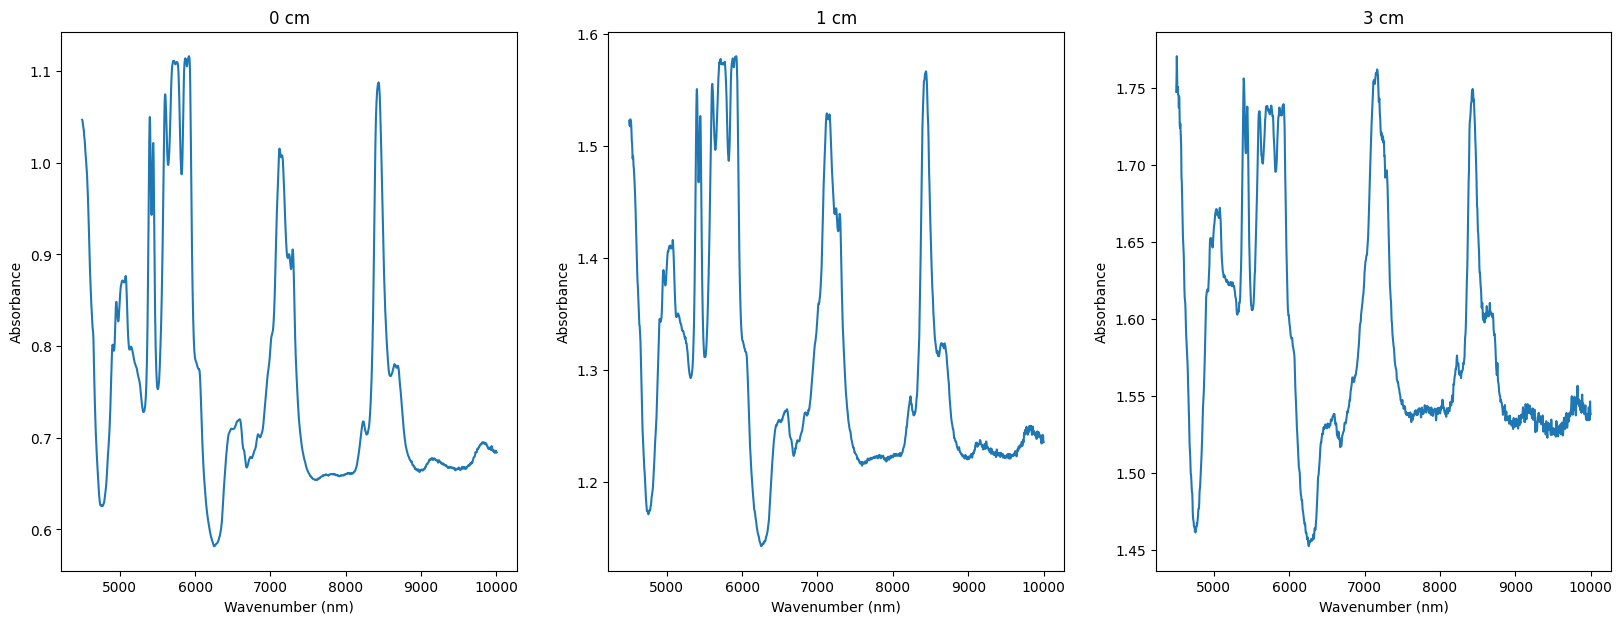

In [7]:
fig, axs = plt.subplots(1,3, figsize=(20,7))
for ax, label in zip(axs.flatten(), labels):
    mean_data = data_exp1.loc[label].mean()
    ax.plot(data_exp1.columns, mean_data, label=label)
    ax.set_xlabel("Wavenumber (nm)")
    ax.set_ylabel("Absorbance")
    ax.set_title(label)

plt.show()

### ML Clustering

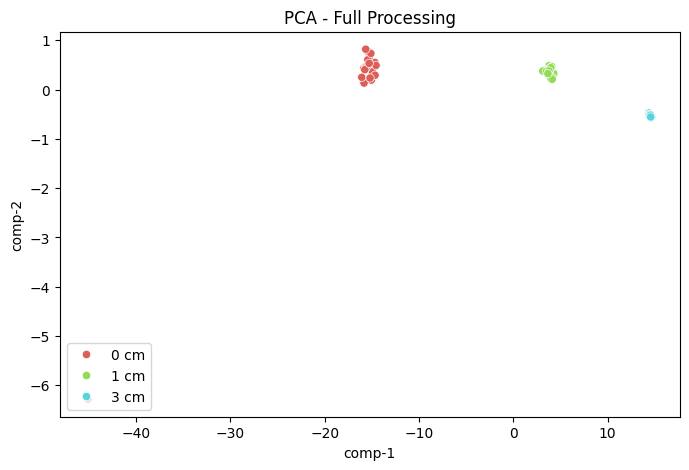

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#read the data
n = len(data_exp1.columns)
X_features = data_exp1.iloc[:, 1:n]
y_label = data_exp1.index

#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
#principalDf = pd.DataFrame(data = principalComponents, columns =['principal component 1', 'principal component 2'])
#principalDf.head(5)
#data[['group']].head()
#finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = principalComponents[:,0]
df["comp-2"] = principalComponents[:,1]

scatter_plot = sns.scatterplot(x="comp-1", 
                               y="comp-2", hue=df.y.tolist(),
                               palette=sns.color_palette("hls", 4),
                               data=df
                               ).set(title="PCA - Full Processing")

plt.legend(loc='lower left')
#plt.savefig('PCA – No Processing.png')
plt.show()

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 62 samples in 0.000s...
[t-SNE] Computed neighbors for 62 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 62 / 62
[t-SNE] Mean sigma: 9.329457
[t-SNE] KL divergence after 250 iterations with early exaggeration: 46.016071
[t-SNE] KL divergence after 900 iterations: 0.009171


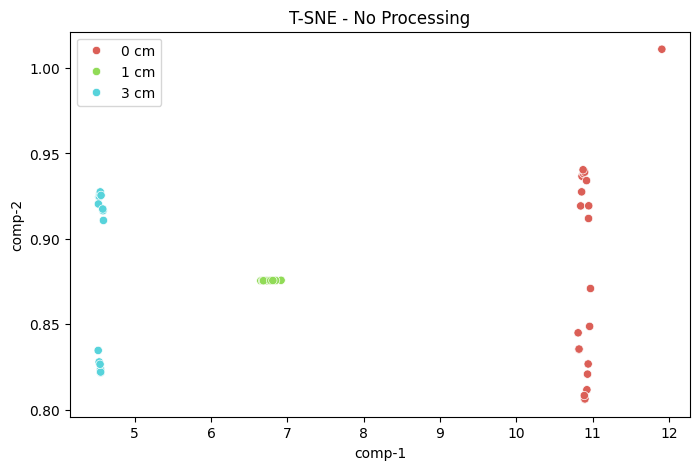

In [21]:
#t-SNE
from sklearn.manifold import TSNE
from numpy import reshape
import seaborn as sns

tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(X_features)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

scatter_plot = sns.scatterplot(x="comp-1", 
                               y="comp-2", 
                               hue=df.y.tolist(),
                               palette=sns.color_palette("hls", 4),
                               data=df
                               ).set(title="T-SNE - No Processing")

Calculating PHATE...
  Running PHATE on 62 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -3.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.02 seconds.
Calculated PHATE in 0.03 seconds.


[Text(0.5, 1.0, 'PHATE - No Processing')]

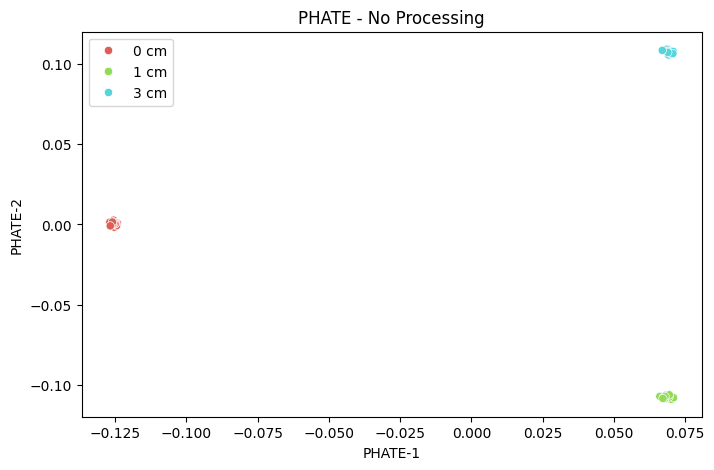

In [23]:
#phate
import phate
phate_op = phate.PHATE()
phate_op.set_params(knn=15, decay=15, t=12)#knn : Number of nearest neighbors (default: 5).
#Increase this (e.g. to 20) if your PHATE embedding appears verydisconnected.
#You should also consider increasing knn if your dataset is extremely large(e.g. >100k cells)
#decay : Alpha decay (default: 15). Decreasing decay increases connectivity on the graph,
#increasing decay decreases connectivity.
#This rarely needs to be tuned. Set it to None for a k-nearest neighbors kernel.

data_phate = phate_op.fit_transform(X_features)
result_phate = pd.DataFrame()
result_phate["y"] = y_label
result_phate["PHATE-1"] = data_phate[:,0]
result_phate["PHATE-2"] = data_phate[:,1]

sns.scatterplot(x="PHATE-1", 
                y="PHATE-2", 
                hue=result_phate.y.tolist(),
                palette=sns.color_palette("hls", 4),
                data=result_phate
                ).set(title="PHATE - No Processing")

# plt.savefig('PHATE – No Processing.png')

[Text(0.5, 1.0, 'UMAP No Processing')]

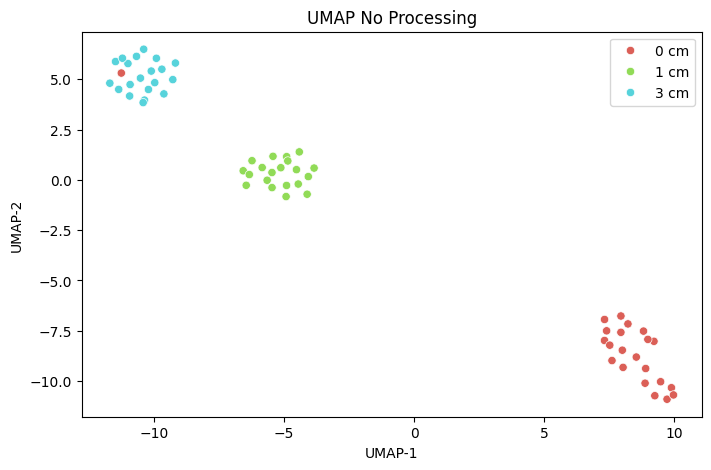

In [11]:
#UMAP
from numpy import reshape
import seaborn as sns
import umap
# import umap.plot

plt.rcParams['figure.figsize'] = (8,5)
#mapper = umap.UMAP().fit(X_features)
#umap.plot.points(mapper, labels=y_label)
embedding = umap.UMAP(n_neighbors=10,
min_dist=0.5,n_components=2,
metric='correlation').fit_transform(X_features)
result = pd.DataFrame()
result["y"] = y_label
result["UMAP-1"] = embedding[:,0]
result["UMAP-2"] = embedding[:,1]

sns.scatterplot(x="UMAP-1", 
                y="UMAP-2", 
                hue=result.y.tolist(),
                palette=sns.color_palette("hls", 4),
                data=result
                ).set(title="UMAP No Processing")

## Experiment 2

### Load Data

In [12]:
fps = ["./data/exp2/PEG/*.csv", "./data/exp2/PMMA/*.csv", "./data/exp2/unknown/*.csv"]
labels = ["PEG", "PMMA", "Unknown"]

In [13]:
data_exp2 = no_processing(fps, labels)
cols_to_drop = [col for col in data_exp2.columns if col <= 4500] # Columns with wavenumber <= 4500 are dropped
data_exp2 = data_exp2.drop(columns=cols_to_drop)
data_exp2

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.040,4531.896,4535.754,...,9966.316,9970.173,9974.030,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.030
PEG,0.864915,0.858870,0.854199,0.850525,0.843326,0.839720,0.842355,0.837627,0.828287,0.826522,...,0.782098,0.779417,0.776712,0.775836,0.776892,0.779561,0.776760,0.778662,0.783519,0.780815
PEG,0.684170,0.685232,0.681629,0.672946,0.672773,0.671564,0.666317,0.664842,0.661063,0.658416,...,0.702849,0.708174,0.707115,0.708452,0.707894,0.703678,0.704782,0.705600,0.707601,0.709584
PEG,0.873272,0.869316,0.860897,0.860259,0.862863,0.859016,0.851960,0.846104,0.840075,0.838731,...,0.777490,0.776616,0.777691,0.776950,0.778269,0.773844,0.771711,0.780303,0.779277,0.774569
PEG,0.845163,0.847354,0.844056,0.836383,0.830935,0.828999,0.823512,0.821890,0.816641,0.813114,...,0.758331,0.755420,0.758302,0.762809,0.759224,0.758066,0.755000,0.753811,0.753715,0.755297
PEG,0.839253,0.836995,0.834176,0.832469,0.816548,0.809628,0.810753,0.811453,0.811052,0.805666,...,0.734810,0.735491,0.738392,0.739730,0.739657,0.742244,0.741598,0.739610,0.741031,0.740418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unknown,0.726383,0.728600,0.732041,0.730612,0.730359,0.731640,0.731617,0.738260,0.741887,0.747352,...,0.391024,0.390603,0.390023,0.389531,0.388486,0.391288,0.393463,0.391015,0.391283,0.389948
Unknown,0.715588,0.722401,0.720876,0.722536,0.733928,0.737460,0.741489,0.739925,0.739123,0.743011,...,0.388417,0.389673,0.389469,0.390804,0.391603,0.393252,0.391434,0.391044,0.389576,0.389979
Unknown,0.814481,0.823887,0.819562,0.817723,0.820398,0.816854,0.818597,0.825849,0.827269,0.832505,...,0.487681,0.485584,0.485300,0.486442,0.487195,0.489192,0.487229,0.485707,0.484558,0.483247
Unknown,0.731040,0.734379,0.737086,0.735689,0.737343,0.745489,0.748023,0.749761,0.752370,0.755201,...,0.400166,0.398518,0.397959,0.399456,0.399333,0.398645,0.398320,0.398003,0.396677,0.396739


### Plot Spectrum

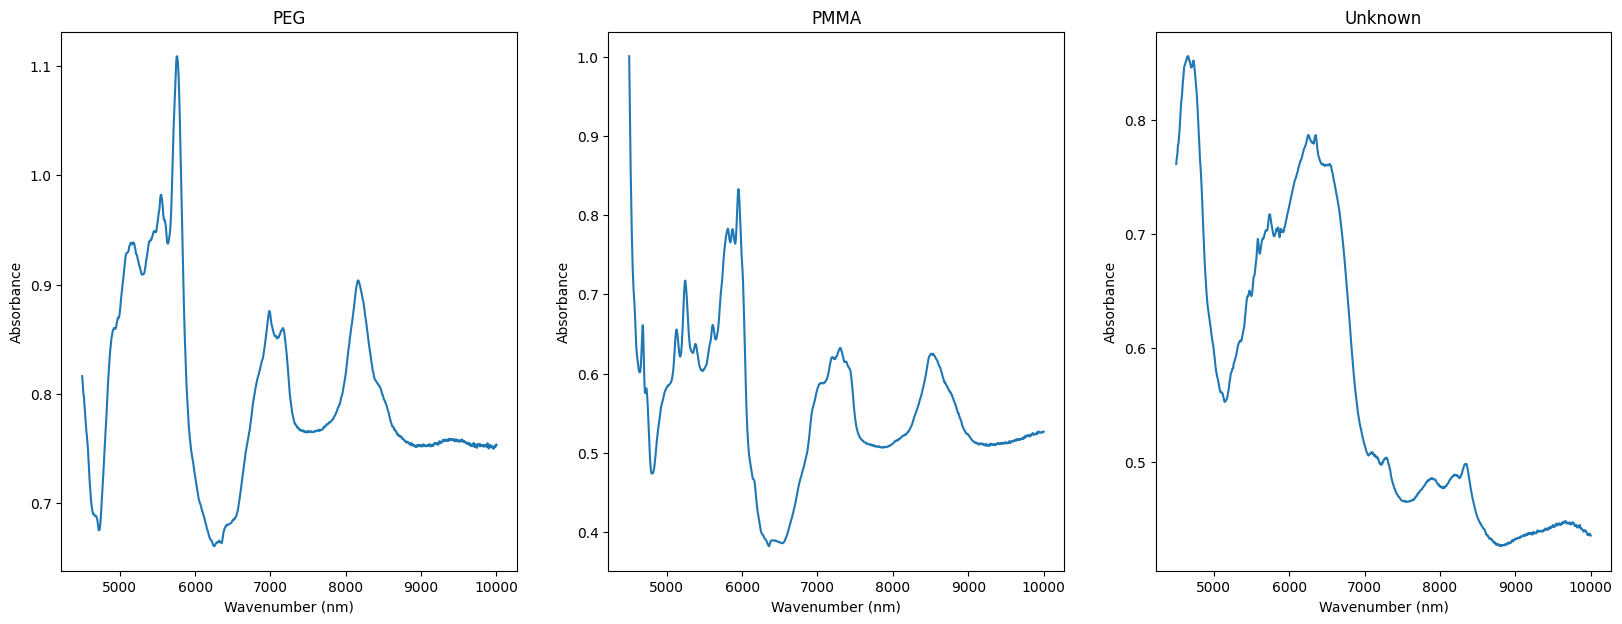

In [15]:
fig, axs = plt.subplots(1,3, figsize=(20,7))
for ax, label in zip(axs.flatten(), labels):
    mean_data = data_exp2.loc[label].mean()
    ax.plot(data_exp2.columns, mean_data, label=label)
    ax.set_xlabel("Wavenumber (nm)")
    ax.set_ylabel("Absorbance")
    ax.set_title(label)

plt.show()

### ML Clustering

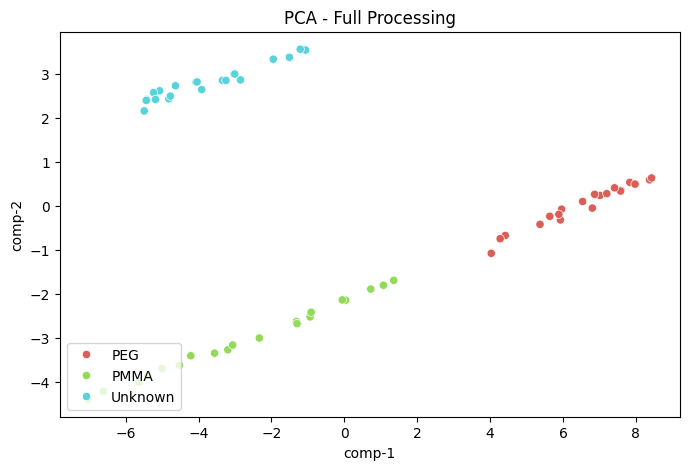

In [16]:
#read the data
n = len(data_exp2.columns)
X_features = data_exp2.iloc[:, 1:n]
y_label = data_exp2.index

#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
#principalDf = pd.DataFrame(data = principalComponents, columns =['principal component 1', 'principal component 2'])
#principalDf.head(5)
#data[['group']].head()
#finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = principalComponents[:,0]
df["comp-2"] = principalComponents[:,1]
scatter_plot = sns.scatterplot(x="comp-1", 
                               y="comp-2", 
                               hue=df.y.tolist(),
                               palette=sns.color_palette("hls", 4),
                               data=df
                               ).set(title="PCA - Full Processing")

plt.legend(loc='lower left')
#plt.savefig('PCA – No Processing.png')
plt.show()

[t-SNE] Computing 60 nearest neighbors...
[t-SNE] Indexed 61 samples in 0.000s...
[t-SNE] Computed neighbors for 61 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 61 / 61
[t-SNE] Mean sigma: 4.773907
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.454697
[t-SNE] KL divergence after 700 iterations: 0.029694


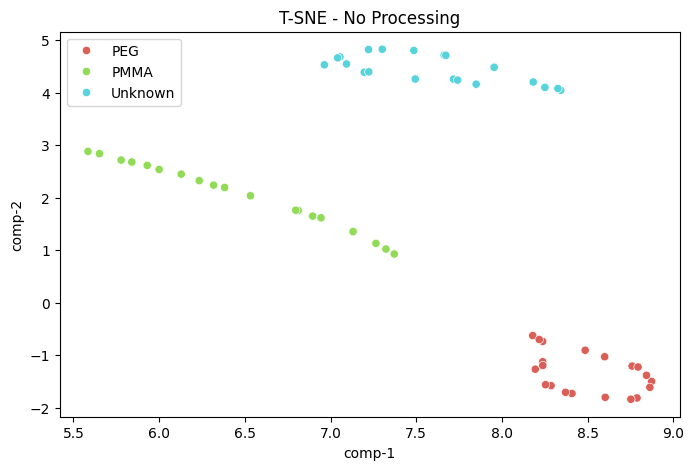

In [17]:
tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(X_features)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

scatter_plot = sns.scatterplot(x="comp-1", 
                               y="comp-2", 
                               hue=df.y.tolist(),
                               palette=sns.color_palette("hls", 4),
                               data=df
                               ).set(title="T-SNE - No Processing")

Calculating PHATE...
  Running PHATE on 61 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 4.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.04 seconds.
Calculated PHATE in 0.05 seconds.


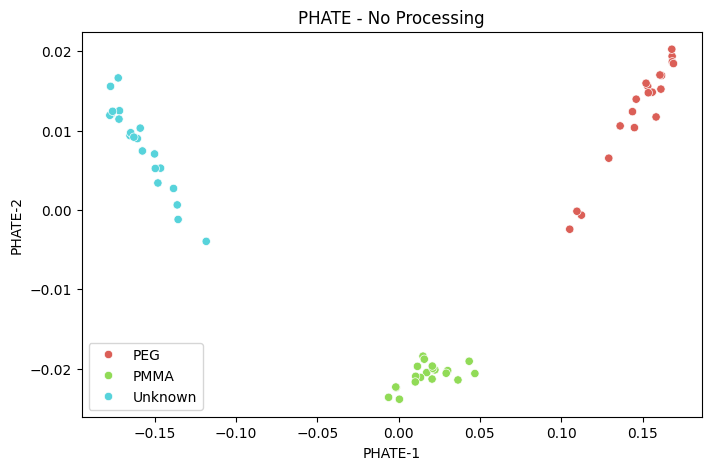

In [18]:
phate_op = phate.PHATE()
phate_op.set_params(knn=15, decay=15, t=12)#knn : Number of nearest neighbors (default: 5).
#Increase this (e.g. to 20) if your PHATE embedding appears verydisconnected.
#You should also consider increasing knn if your dataset is extremely large(e.g. >100k cells)
#decay : Alpha decay (default: 15). Decreasing decay increases connectivity on the graph,
#increasing decay decreases connectivity.
#This rarely needs to be tuned. Set it to None for a k-nearest neighbors kernel.

data_phate = phate_op.fit_transform(X_features)
result_phate = pd.DataFrame()
result_phate["y"] = y_label
result_phate["PHATE-1"] = data_phate[:,0]
result_phate["PHATE-2"] = data_phate[:,1]

sns.scatterplot(x="PHATE-1", 
                y="PHATE-2", 
                hue=result_phate.y.tolist(),
                palette=sns.color_palette("hls", 4),
                data=result_phate
                ).set(title="PHATE - No Processing")

# plt.savefig('PHATE – No Processing.png')

[Text(0.5, 1.0, 'UMAP No Processing')]

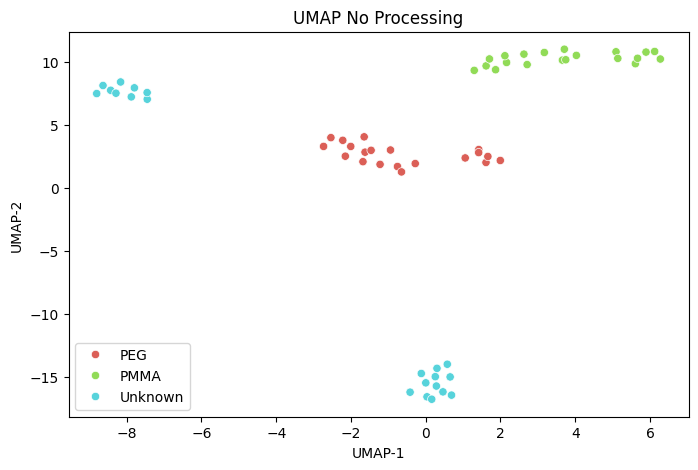

In [19]:
plt.rcParams['figure.figsize'] = (8,5)
#mapper = umap.UMAP().fit(X_features)
#umap.plot.points(mapper, labels=y_label)
embedding = umap.UMAP(n_neighbors=10,
min_dist=0.5,n_components=2,
metric='correlation').fit_transform(X_features)
result = pd.DataFrame()
result["y"] = y_label
result["UMAP-1"] = embedding[:,0]
result["UMAP-2"] = embedding[:,1]

sns.scatterplot(x="UMAP-1", 
                y="UMAP-2", 
                hue=result.y.tolist(),
                palette=sns.color_palette("hls", 4),
                data=result
                ).set(title="UMAP No Processing")